In [ ]:
# In this attempt, we will try to accomplish the following  deterministically or stochastically:
# 1) Predict the dimensions of the tests
# 2) Predict the set of output values of tests
# From here, use the prior knowledge to
# 3) predict the tuples of transformation of the tests
# 4) then predict the tests by offering 3 candidate solutions

# The current attempt is more formalized in terms of prior knoweldge
# We will have to ground serious set operations and sequence completion
# algorithms, we already started this

In [1]:
# Factors for predicting dimensions
# Factors for predicting the outputs
from ARCsolver import *

In [2]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)

In [3]:
this_analysis = []
for n in range(len(tt)):
    #print(n)
    this_task = ARCsolver(tt[n])
    this_analysis.append(this_task)

In [4]:
# for classic prior knowledge
deduced = 0
for n in this_analysis:
    if n.dimension_status == 'deduced':
        deduced += 1
deduced # 363, 362, 361, 360

360

In [ ]:
# case 14: must allow singles of different colors to make shape

In [5]:
# this_object_data: 0:5 
# [vals[target_ind], counts[target_ind], vals[max_index], counts[max_index], vals[min_index],  counts[min_index],  len(vals), sum(counts)]
#        6                 7                 8               9                 10                11                 12           13     

# 30
# is_out_in_rel: True, (True, [(0, (2, 3))], 'contraction')
# is_out_obj_in_in_objs: [(True, 0)]
# overall_movement: [(True, (2, 3))]
# 299
# (True, [(0, (1, 1))], 'contraction')
# is_out_obj_in_in_objs: [(True, 2)]
# overall_movement: [(True, (1, 1))]

# 38: (True, [(0, (2, 2)), (5, (2, 5)), (3, (5, 2)), (2, (5, 5))], 'contraction'): output upper corner of an object
# 66: (True, [(0, (0, 0)), (3, (0, 3)), (0, (0, 6))], 'contraction'): output left or right half
# 82: (True, [(0, (0, 0)), (4, (0, 4)), (0, (3, 0)), (4, (3, 4))], 'expansion'): here, we 
# just initiate zero, add the input to the first quarter, and the 4 rotame in the second
# quarter, etc, notice, the order of populating rotamers may change with in the same case
# output more predictions or go with the consensus
# 105: (True, [(0, (0, 0)), (3, (0, 2)), (3, (2, 0)), (0, (2, 2))], 'expansion') same as above
# 115: (True, [(6, (0, 0)), (0, (3, 0))], 'expansion')
# 141: (True, [(0, (0, 0)), (7, (0, 3)), (6, (3, 0)), (4, (3, 3))], 'expansion')
# 151: (True, [(0, (0, 0)), (7, (0, 3)), (6, (3, 0)), (4, (3, 3))], 'expansion')
# 163 (True, [(0, (0, 0)), (7, (0, 3))], 'expansion')
# 103: (True, [(0, (0, 0)), (5, (0, 3)), (3, (3, 0)), (4, (3, 3))], 'expansion')
# 209: (True, [(0, (0, 0)), (6, (3, 0))], 'expansion')
# 210 (True, [(4, (0, 0)), (0, (0, 2)), (4, (3, 0)), (0, (3, 2)), (4, (6, 0)), (0, (6, 2))], 'expansion')
# last one is quite interesting
# 230: special case of 210, (True, [(0, (0, 0)), (7, (0, 1)), (0, (0, 2)), (7, (0, 3)), (0, (0, 4)), (7, (0, 5)), (0, (0, 6))], 'expansion')
# 241: (True, [(5, (4, 8)), (7, (5, 9)), (6, (8, 4)), (4, (8, 9)), (3, (9, 5)), (2, (9, 8))], 'contraction')
# last one is an indication the output is a transform of many parts of the rest
# 248: (True, [(0, (0, 0)), (0, (0, 3))], 'expansion')
# 204 (True, [(0, (0, 0))], 'expansion') is unacceptable
# 309: (True, [(0, (5, 5))], 'contraction')
# is_out_obj_in_in_objs: [(True, 40), (True, 54), (True, 64), (True, 81)]
# overall_movement: [(True, (5, 5)), (True, (5, 5)), (True, (5, -1)), (True, (5, 5))]
# output is the largest object starts with 5, 5
# 310: simple expansion (True, [(0, (0, 0)), (7, (0, 3))], 'expansion')


# 48 output the smallest [True, 0]
# [11, 21, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72]
# [0, 10, 0, 10, 10, 10, 2, 72, 2, 72, 2, 72, 1, 72]
# 121: basic object movement to check and apply right away (same dim couple)
# here multiple movements may be recommended, stick to the options you have
# 


# 139 solved with flips show as: overall_movement: [(True, (-1, -1))]
# 
def is_out_obj_in_in_objs(out_obj, in_objs):
    for obj in range(len(in_objs)):
        if in_objs[obj][4:14] == out_obj[4:14]:
            return True, obj
    return False, -1

def direct_obj_movement_detection(out_obj, in_objs):
    is_in, ind = is_out_obj_in_in_objs(out_obj, in_objs)
    if is_in:
        # Test movement
        is_move_vert = in_objs[ind][0] != out_obj[0]
        is_move_hori = in_objs[ind][2] != out_obj[2]
        if is_move_vert or is_move_hori:
            return True, (in_objs[ind][0] - out_obj[0], in_objs[ind][2] - out_obj[2])
    return False, ()
    
def overall_movement(out_objs, in_objs):
    moved = []
    for n in range(len(out_objs)):
        moved.append(direct_obj_movement_detection(out_objs[n], in_objs))
    return moved


In [7]:
to_inspect = [173, 212, 215, 232, 299, 324, 364, 395]

In [34]:
tests

46

0
expansion:
[[0, 4, 0, 0, 4, 0, 4, 0, 0, 4, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0, 0, 0], [0, 7, 0, 7, 0, 0, 7, 0]] [[(0, 3), (0, 4), (0, 6), (3, 0), (3, 1), (3, 3), (3, 4), (3, 6), (6, 3), (6, 4), (6, 6)], [(0, 0), (0, 6), (6, 3)], [(3, 6), (6, 0), (6, 6)], [(0, 0), (0, 3), (3, 0), (6, 3), (6, 6)], [(0, 0), (0, 1), (0, 3), (0, 4), (0, 6), (6, 3), (6, 4), (6, 6)]]


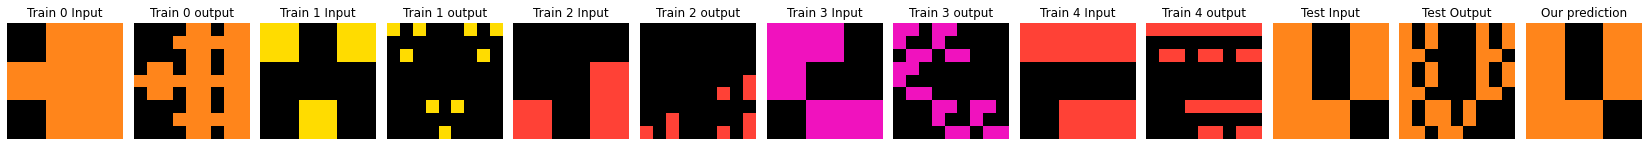

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
13
contraction:
[[0], [0], [0]] [[(11, 0)], [(11, 10)], [(10, 0)]]


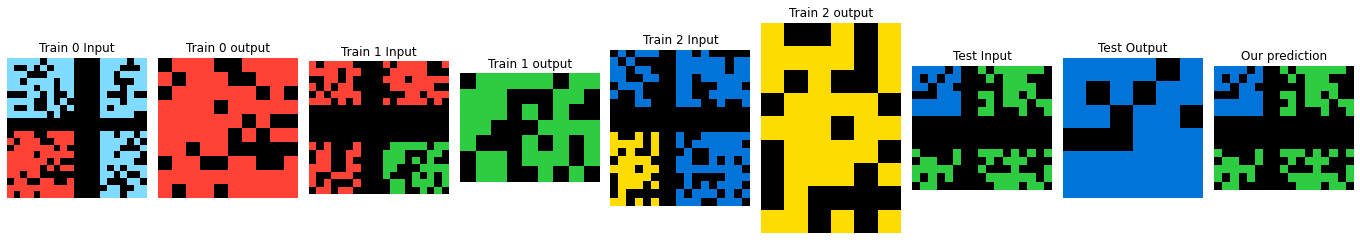

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (11, 0))]
20
contraction:
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]] [[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (9, 2), (9, 3), (9, 4), (9, 5), (9, 6), (10, 2), (10, 3), (10, 4), (10, 5), (10, 6), (11, 2), (11, 3), (11, 4), (11, 5), (11, 6), (12, 2), (12, 3), (12, 4), (12, 5), (12, 6), (13, 2), (13, 3), (13, 4), (13, 5), (13, 6)], [(0, 0), (0, 1), (0

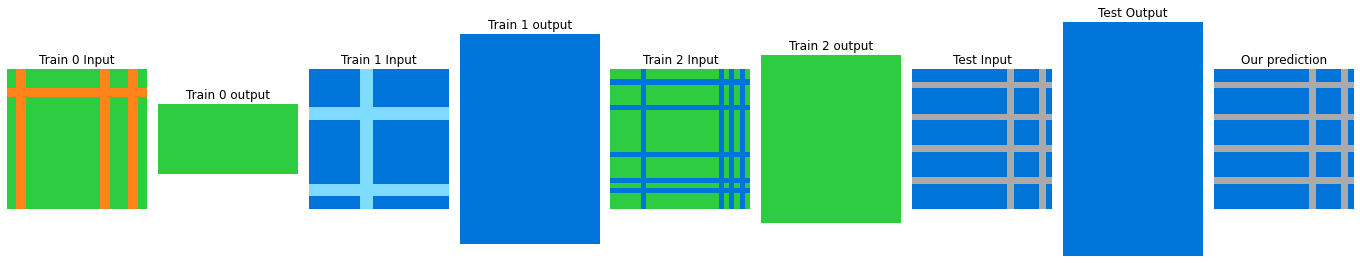

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
28
contraction:
[[0], [0], [0]] [[(4, 5)], [(7, 3)], [(3, 4)]]


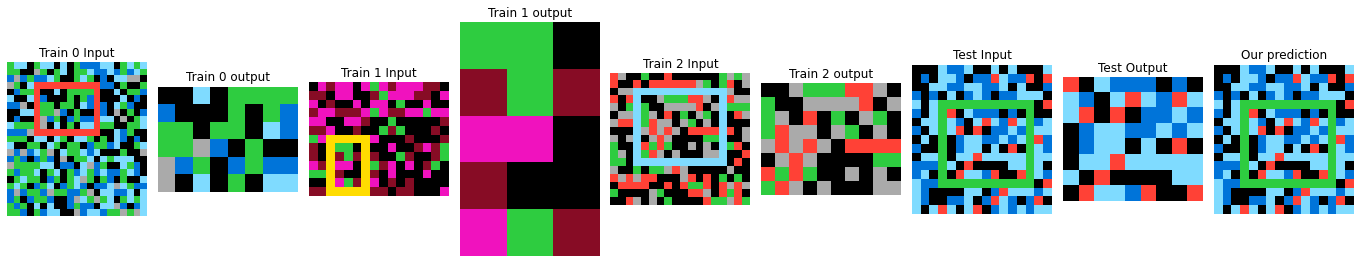

is_out_obj_in_in_objs: [(True, 8), (True, 11), (True, 10), (True, 22), (True, 14), (True, 37), (True, 67)]
overall_movement: [(True, (4, 5)), (True, (14, 13)), (True, (9, 10)), (True, (4, 5)), (True, (-5, -5)), (True, (4, 5)), (True, (4, 5))]
30
contraction:
[[0], [0], [0]] [[(2, 3)], [(1, 2)], [(3, 3)]]


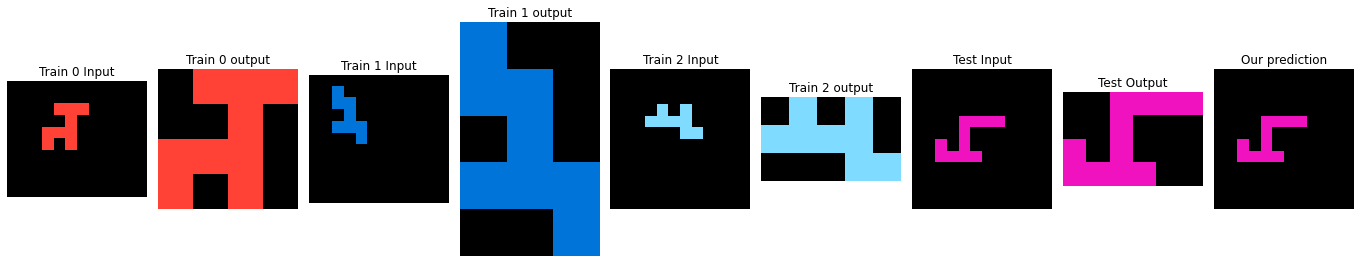

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (2, 3))]
35
contraction:
[[0], [0]] [[(10, 17)], [(9, 11)]]


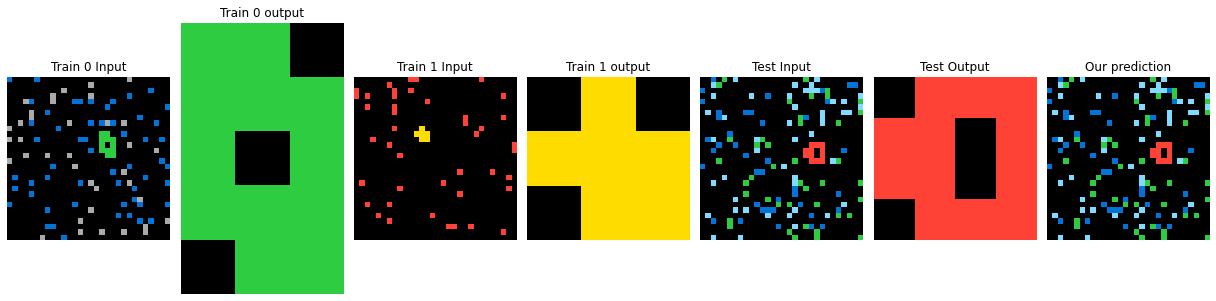

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (10, 17))]
38
contraction:
[[0, 5, 3, 2], [0, 5, 3, 4]] [[(2, 2), (2, 5), (5, 2), (5, 5)], [(1, 1), (1, 4), (4, 1), (4, 4)]]


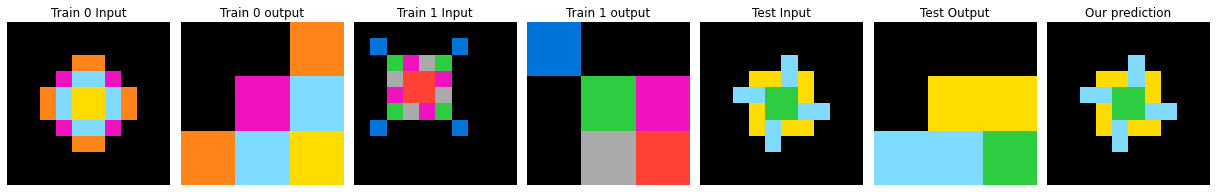

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
48
contraction:
[[0], [0], [0], [0], [0]] [[(5, 3)], [(15, 14)], [(5, 5)], [(4, 3)], [(3, 11)]]


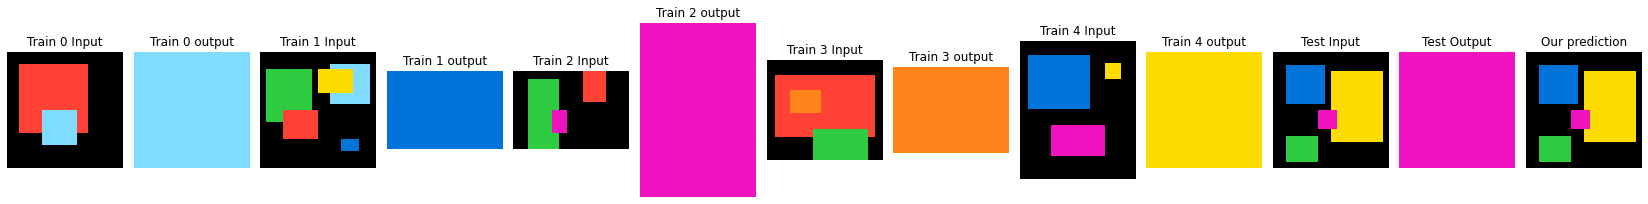

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (5, 3))]
64
contraction:
[[0], [0], [0]] [[(3, 0)], [(0, 4)], [(0, 0)]]


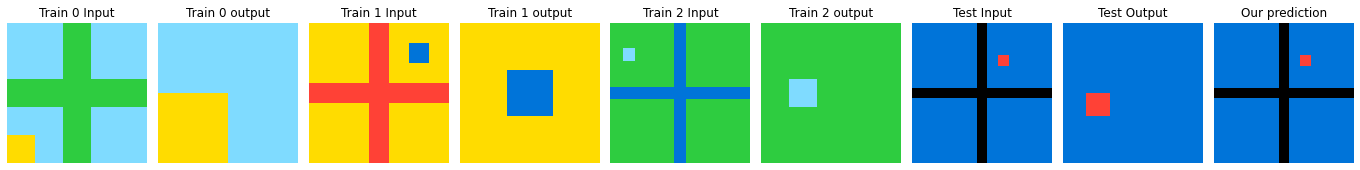

is_out_obj_in_in_objs: [(True, 3)]
overall_movement: [(True, (3, 0))]
66
contraction:
[[0, 3, 0], [0, 0, 0], [0, 7, 0, 7, 0]] [[(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 4), (0, 8)], [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]]


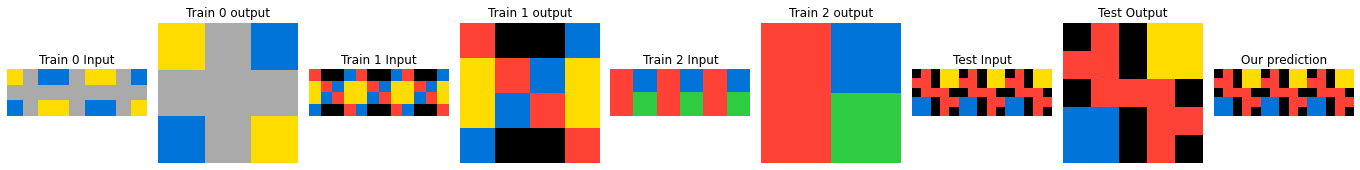

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
78
contraction:
[[0, 0, 0], [0, 0, 0, 0], [0, 0]] [[(1, 2), (2, 10), (7, 3)], [(1, 2), (3, 11), (8, 9), (10, 2)], [(2, 2), (8, 8)]]


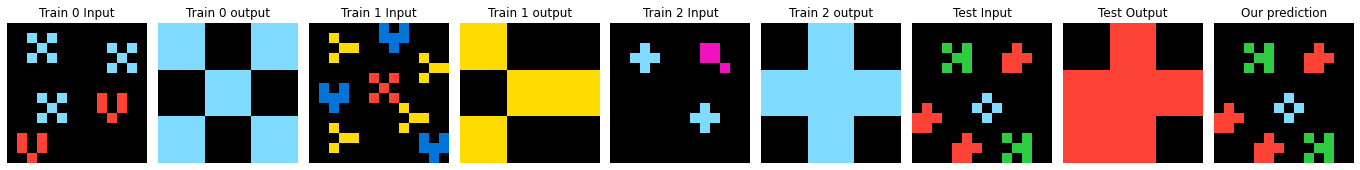

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 2))]
82
expansion:
[[0, 4, 0, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)], [(0, 0), (0, 4), (3, 0), (3, 4)]]


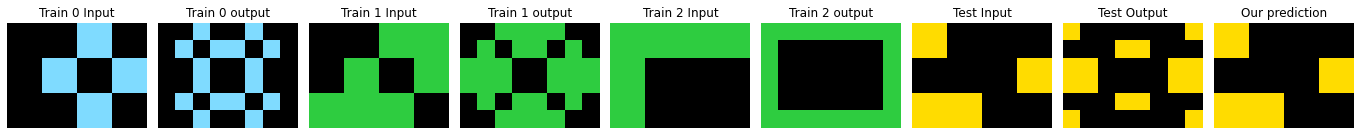

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
90
contraction:
[[0], [0], [0]] [[(1, 1)], [(3, 2)], [(2, 3)]]


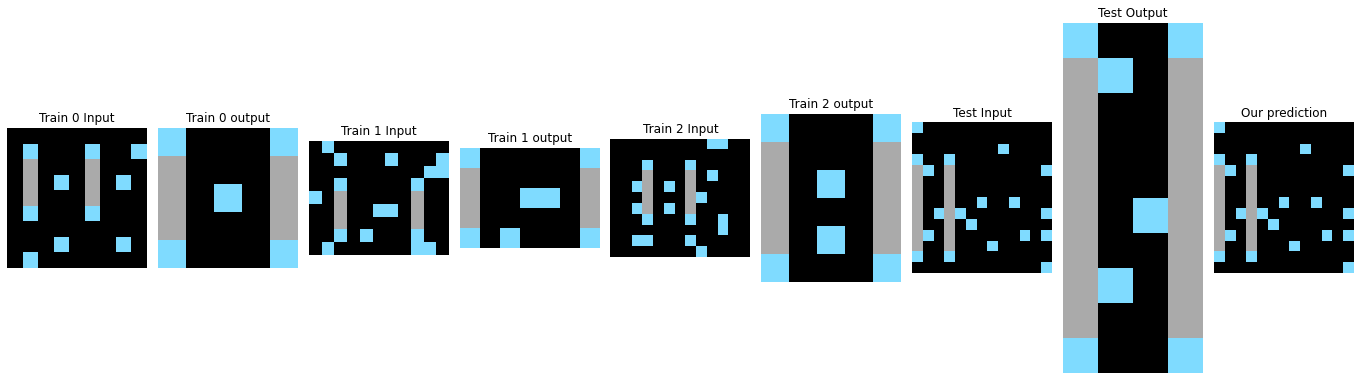

is_out_obj_in_in_objs: [(True, 0), (True, 0)]
overall_movement: [(True, (1, -3)), (True, (1, 1))]
105
expansion:
[[0, 3, 3, 0], [0, 5, 3, 2], [0, 5, 3, 4]] [[(0, 0), (0, 2), (2, 0), (2, 2)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


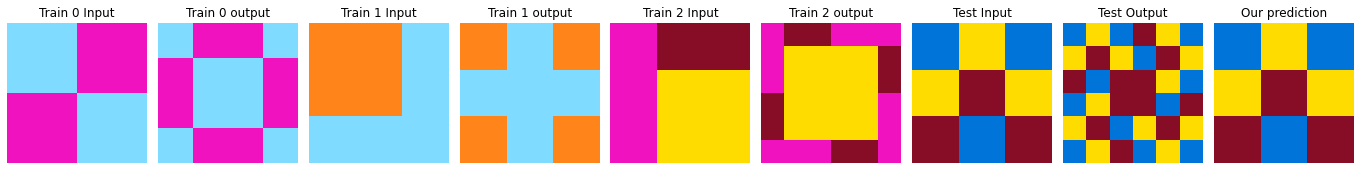

is_out_obj_in_in_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]
110
contraction:
[[0], [0], [0]] [[(3, 2)], [(2, 6)], [(5, 6)]]


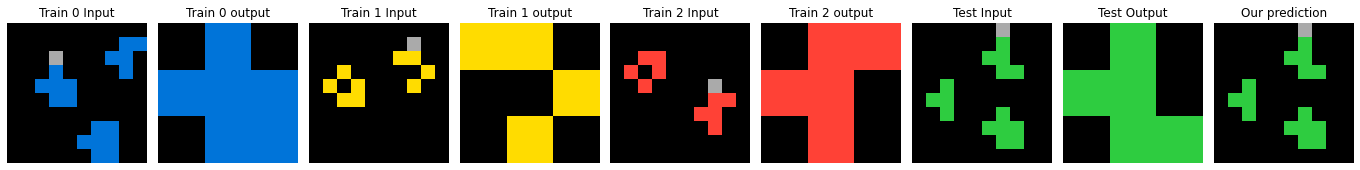

is_out_obj_in_in_objs: [(True, 1)]
overall_movement: [(True, (3, 2))]
115
expansion:
[[6, 0], [6, 0], [6, 0], [6, 0]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


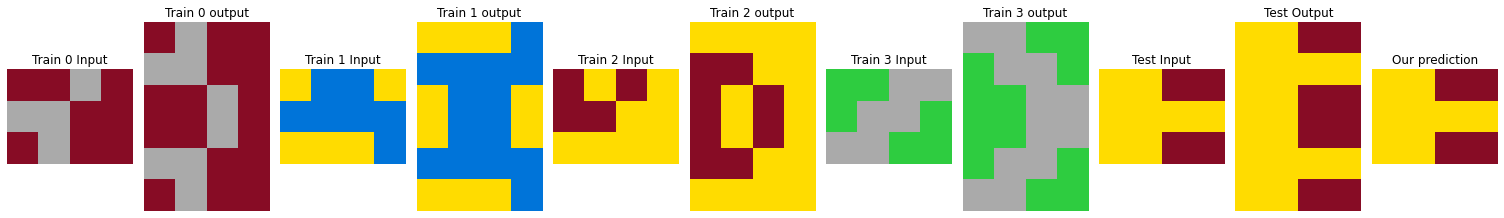

is_out_obj_in_in_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]
134
contraction:
[[0], [0], [0], [0]] [[(0, 6)], [(0, 6)], [(0, 6)], [(0, 6)]]


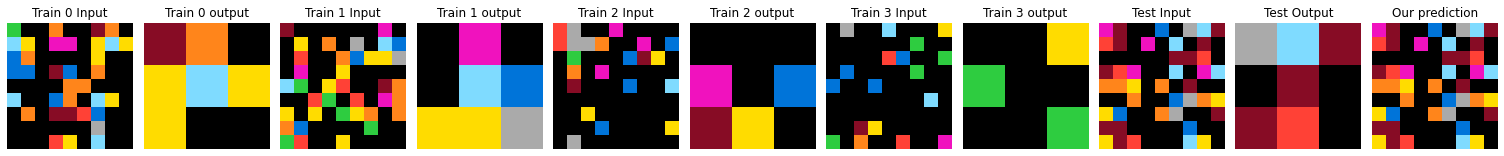

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (0, 6))]
141
expansion:
[[0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


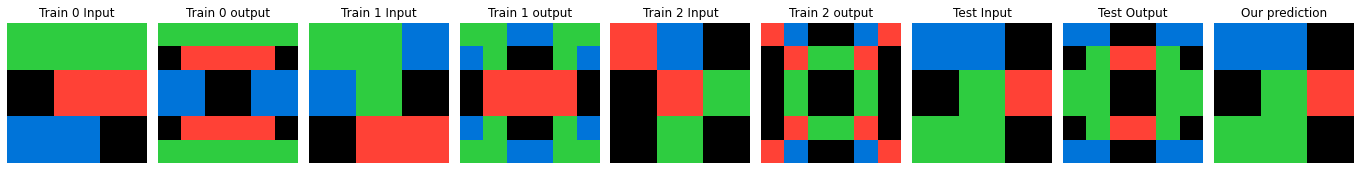

is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ()), (False, ())]
145
contraction:
[[0], [0], [0], [0]] [[(6, 0)], [(3, 0)], [(6, 0)], [(0, 0)]]


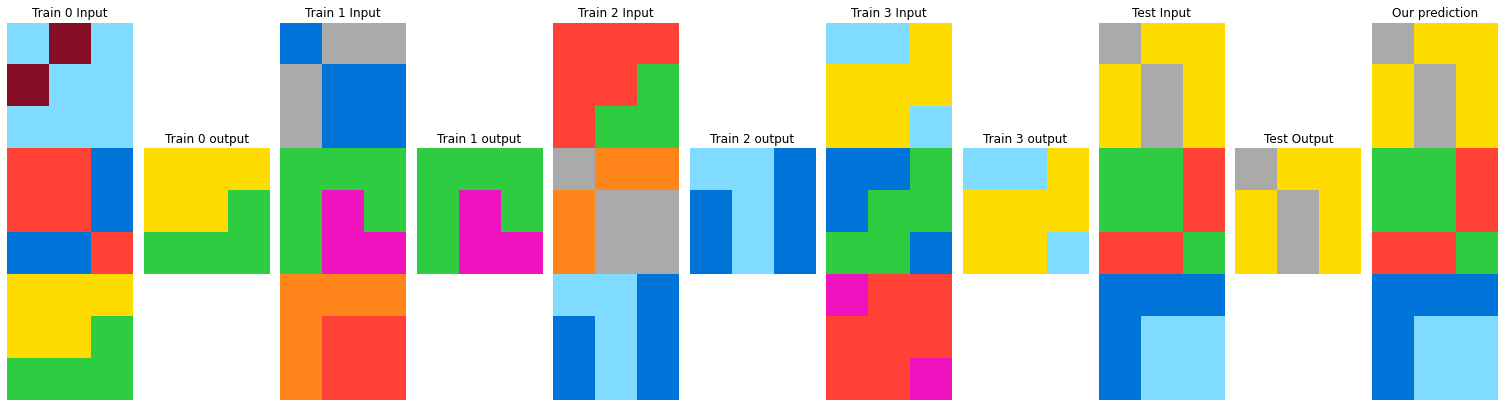

is_out_obj_in_in_objs: [(True, 3), (True, 5)]
overall_movement: [(True, (6, 0)), (True, (6, 0))]
151
expansion:
[[0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4], [0, 7, 6, 4]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


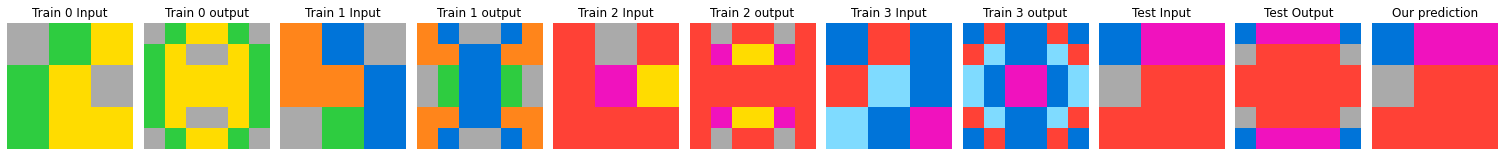

is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ()), (False, ())]
163
expansion:
[[0, 7], [0, 7], [0, 7], [0, 7]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)]]


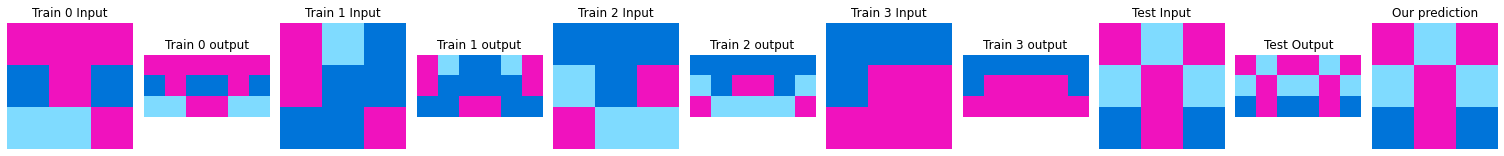

is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 0), (True, 0)]
overall_movement: [(False, ()), (False, ()), (True, (0, -4)), (False, ())]
171
expansion:
[[0, 6], [0, 4], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


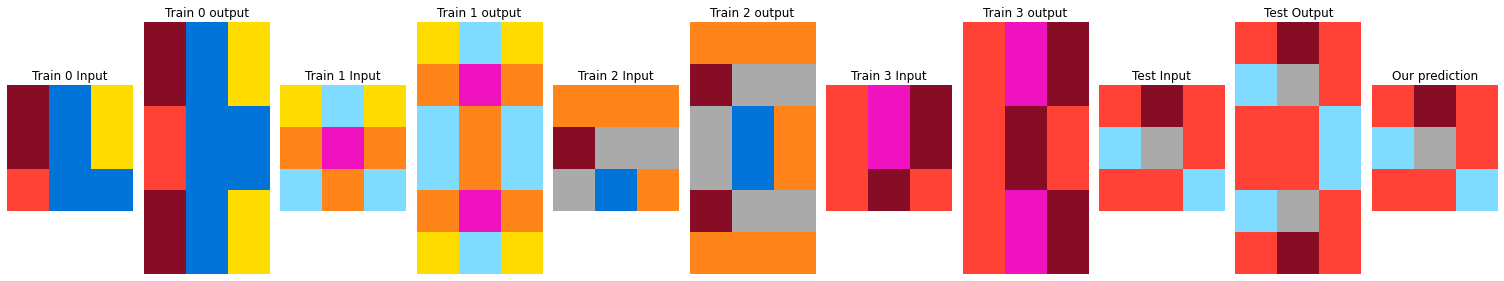

is_out_obj_in_in_objs: [(False, -1), (True, 0), (False, -1), (True, 0), (True, 1), (True, 1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-4, 0)), (False, ()), (True, (-4, 0))]
173
contraction:
[[0], [0], [0]] [[(6, 3)], [(1, 2)], [(2, 5)]]


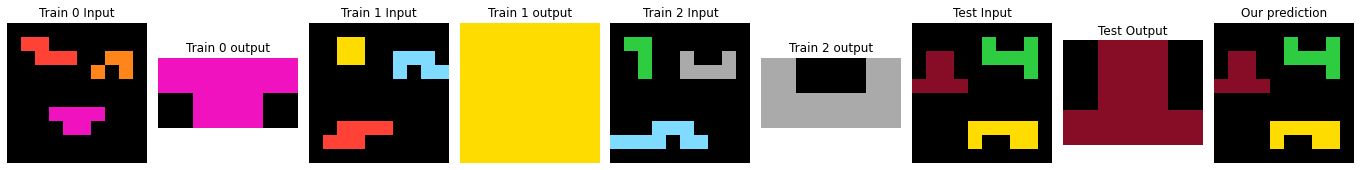

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (6, 3))]
176
contraction:
[[7], [7], [7]] [[(5, 2)], [(1, 3)], [(7, 2)]]


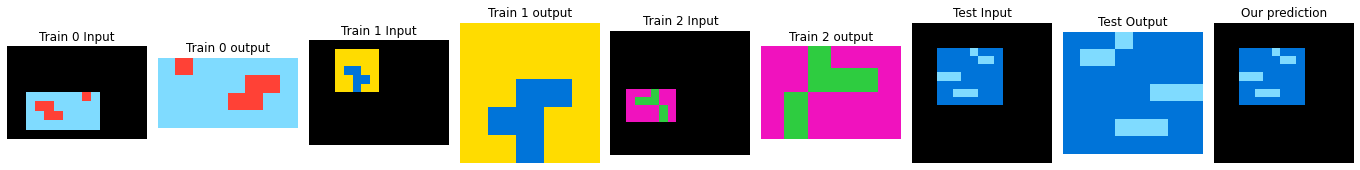

is_out_obj_in_in_objs: [(True, 0), (True, 1)]
overall_movement: [(True, (5, 2)), (True, (5, -1))]
187
contraction:
[[0, 0], [0, 0], [0, 4, 0]] [[(0, 0), (0, 4)], [(0, 0), (0, 3)], [(0, 0), (2, 0), (3, 0)]]


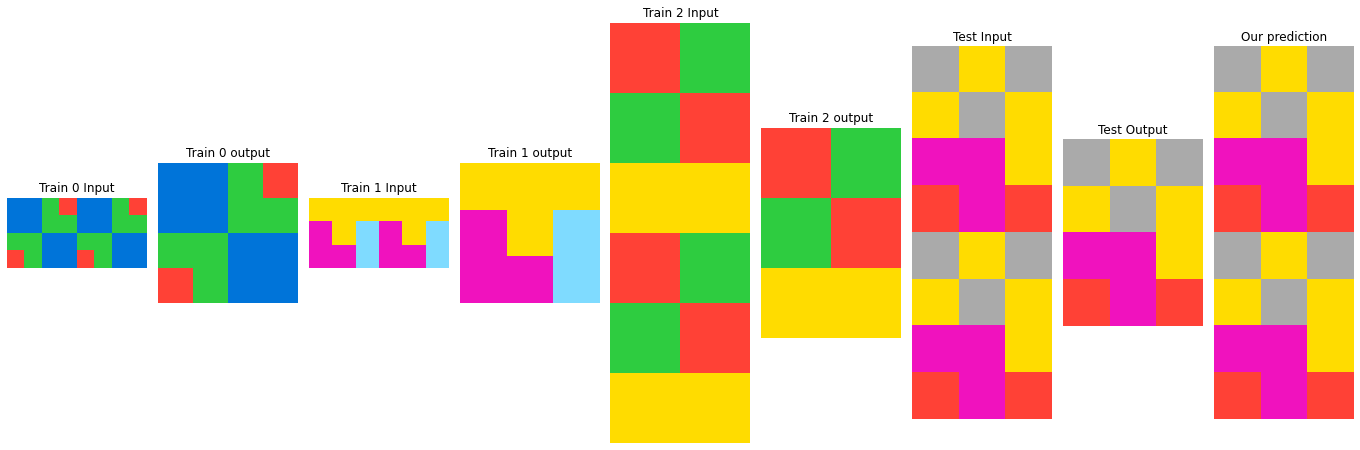

is_out_obj_in_in_objs: [(False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ())]
193
expansion:
[[0, 5, 3, 4], [0, 5, 3, 4], [0, 1, 1, 0]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)], [(0, 0), (0, 3), (3, 0), (3, 3)]]


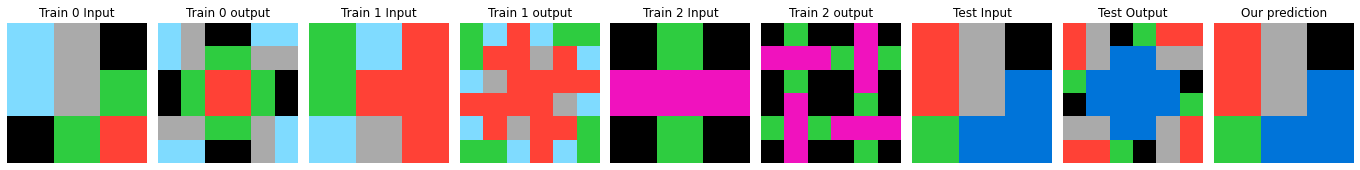

is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (False, -1), (False, -1), (True, 0), (True, 1), (True, 0), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (True, (-4, -3)), (False, ()), (False, ()), (False, ()), (False, ()), (True, (-4, -5)), (False, ()), (False, ())]
206
contraction:
[[2, 2, 2, 0], [0], [0]] [[(0, 0), (0, 3), (3, 0), (3, 3)], [(3, 0)], [(0, 3)]]


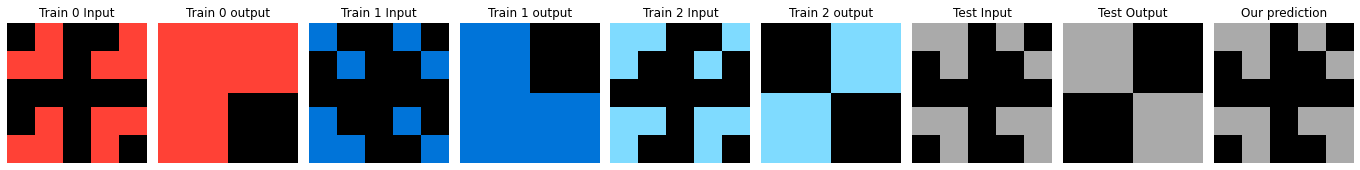

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (0, 3))]
209
expansion:
[[0, 6], [0, 6], [0, 6]] [[(0, 0), (3, 0)], [(0, 0), (3, 0)], [(0, 0), (3, 0)]]


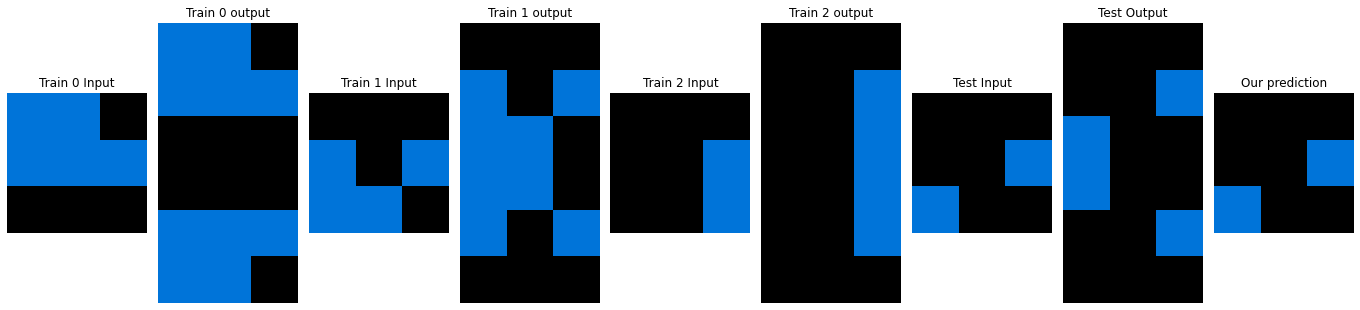

is_out_obj_in_in_objs: [(True, 0), (True, 0)]
overall_movement: [(False, ()), (True, (-4, 0))]
210
expansion:
[[4, 0, 4, 0, 4, 0], [4, 0, 4, 0, 4, 0], [4, 6, 7, 0, 4, 6]] [[(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)], [(0, 0), (0, 2), (3, 0), (3, 2), (6, 0), (6, 2)]]


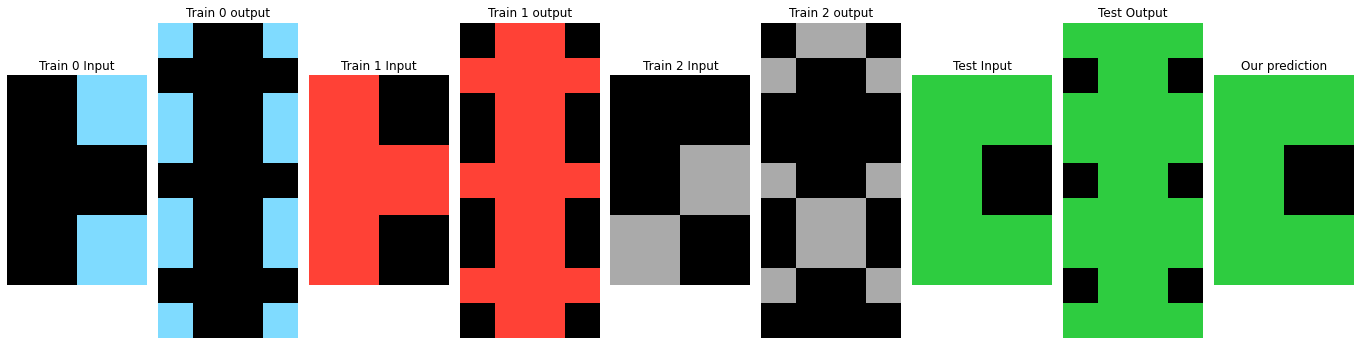

is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (False, ())]
215
contraction:
[[0], [0], [0]] [[(13, 6)], [(2, 2)], [(15, 2)]]


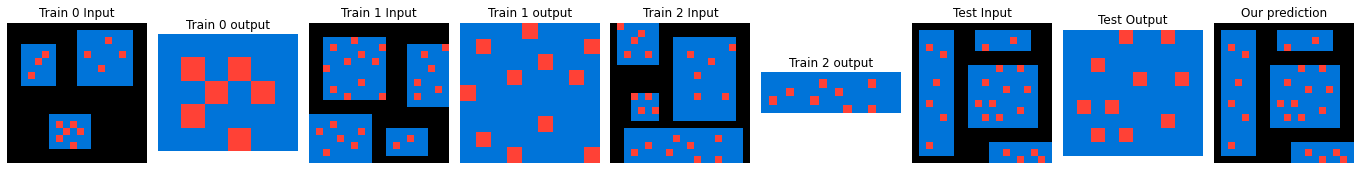

is_out_obj_in_in_objs: [(True, 1), (True, 2)]
overall_movement: [(True, (13, 6)), (True, (13, 6))]
220
expansion:
[[0, 0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 6, 6, 6, 0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 3), (0, 6), (0, 9), (3, 0)], [(0, 0), (0, 3), (0, 6), (0, 9)], [(0, 0), (0, 3), (0, 6), (2, 0), (2, 3), (2, 6), (3, 0), (3, 3), (3, 6)], [(0, 0), (0, 3), (0, 6)]]


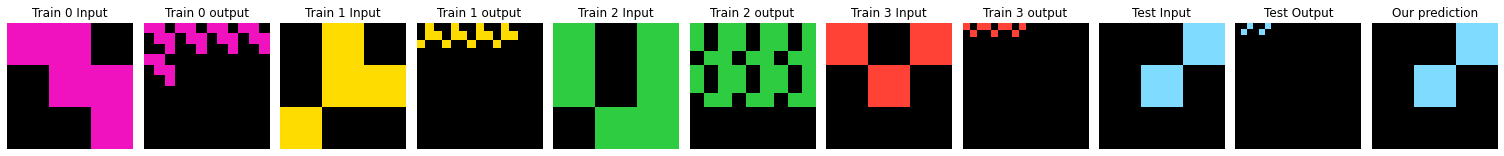

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
230
expansion:
[[0, 7, 0, 7, 0, 7, 0], [0, 0, 0], [0, 0, 0]] [[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6)], [(0, 0), (0, 3), (0, 6)], [(0, 0), (0, 3), (0, 6)]]


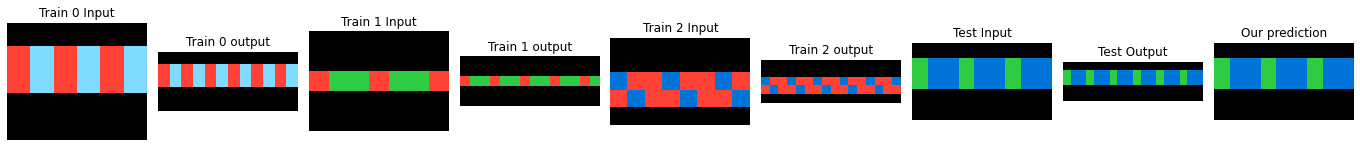

is_out_obj_in_in_objs: [(True, 0), (True, 0), (True, 0), (True, 0), (True, 2), (True, 2), (True, 2), (True, 2), (True, 2), (True, 0), (True, 0), (True, 2)]
overall_movement: [(True, (0, -4)), (False, ()), (True, (0, 4)), (True, (0, -6)), (False, ()), (True, (0, -2)), (True, (0, 4)), (True, (0, -4)), (True, (0, -6)), (True, (0, 2)), (True, (0, -2)), (True, (0, 2))]
241
contraction:
[[5, 7, 6, 4, 3, 2], [5, 1, 6, 4, 7, 3], [2, 3, 4, 7, 5, 1]] [[(4, 8), (5, 9), (8, 4), (8, 9), (9, 5), (9, 8)], [(4, 5), (4, 8), (5, 4), (5, 9), (8, 9), (9, 8)], [(3, 6), (3, 7), (6, 3), (7, 3), (10, 6), (10, 7)]]


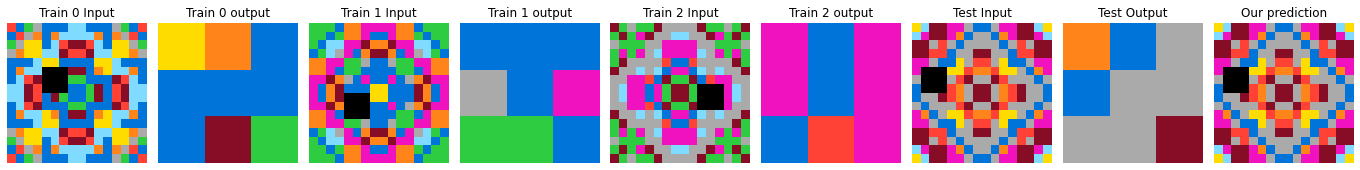

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
248
expansion:
[[0, 0], [0, 0], [0, 0]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 4)]]


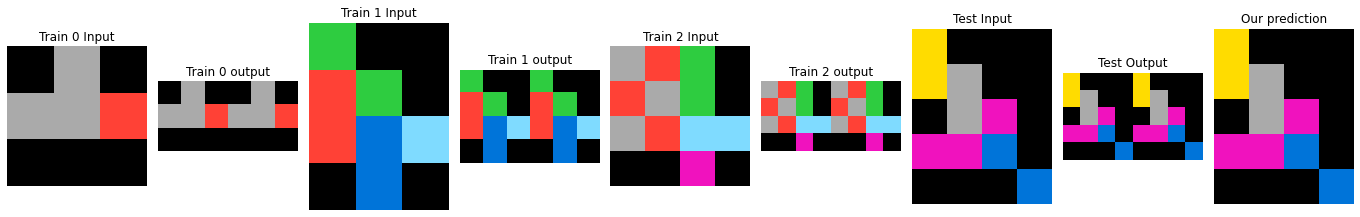

is_out_obj_in_in_objs: [(True, 0), (True, 0)]
overall_movement: [(False, ()), (True, (0, -3))]
262
contraction:
[[0], [0], [0], [0]] [[(6, 0)], [(0, 6)], [(0, 3)], [(0, 0)]]


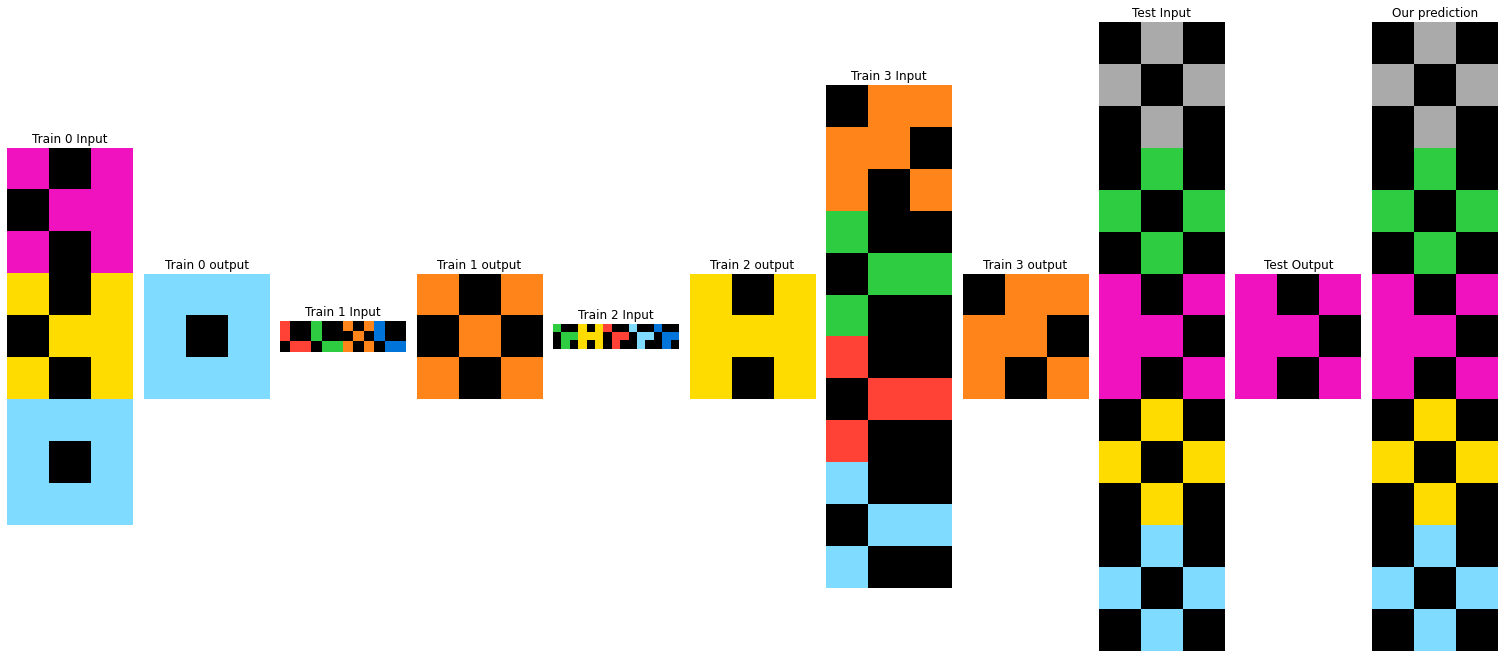

is_out_obj_in_in_objs: [(True, 3)]
overall_movement: [(True, (6, 0))]
270
contraction:
[[0], [0], [0], [0]] [[(5, 6)], [(4, 2)], [(4, 6)], [(1, 6)]]


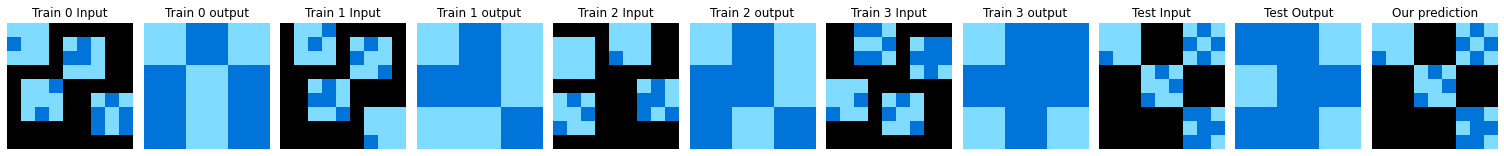

is_out_obj_in_in_objs: [(True, 0), (True, 1)]
overall_movement: [(True, (5, 6)), (True, (5, 6))]
299
contraction:
[[0], [0], [0], [0]] [[(1, 1)], [(1, 4)], [(1, 1)], [(1, 6)]]


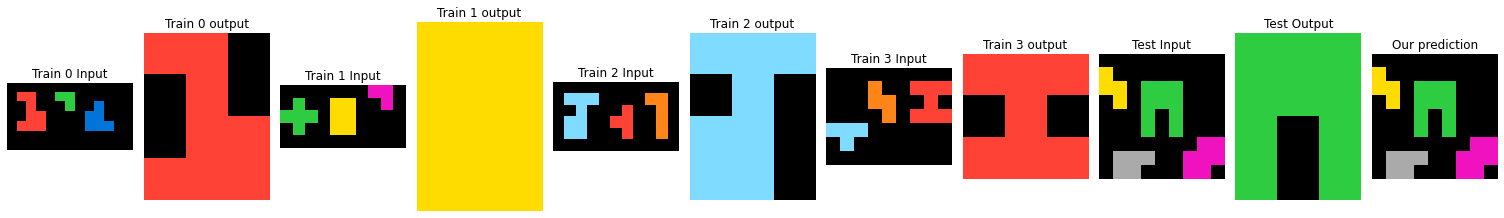

is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 1))]
303
expansion:
[[0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0]] [[(0, 0), (3, 3), (6, 6)], [(0, 0), (0, 6), (3, 6), (6, 0), (6, 3), (6, 6)], [(0, 3), (0, 6), (6, 0), (6, 3)]]


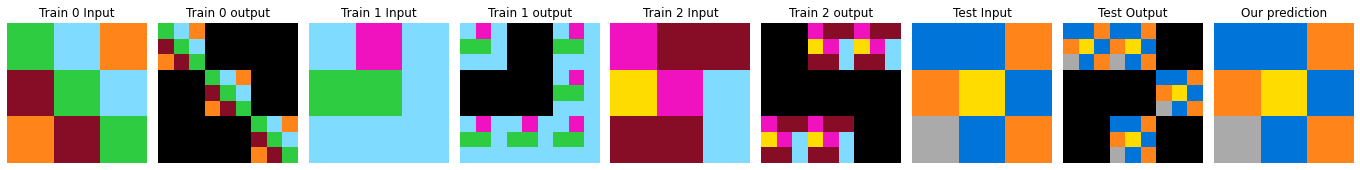

is_out_obj_in_in_objs: [(False, -1), (False, -1), (True, 1), (True, 2), (True, 1), (True, 1), (True, 2), (True, 2)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (-6, -6)), (True, (-6, -6)), (True, (-3, -3)), (True, (-3, -3)), (False, ())]
309
contraction:
[[0], [0], [0]] [[(5, 5)], [(2, 2)], [(17, 5)]]


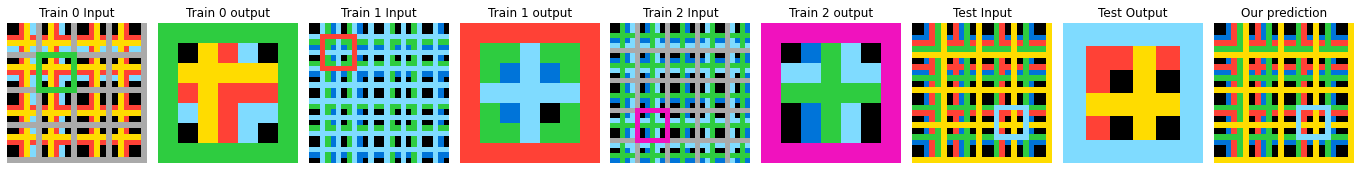

is_out_obj_in_in_objs: [(True, 23), (True, 27), (True, 80), (True, 81)]
overall_movement: [(True, (5, -1)), (True, (5, 5)), (True, (5, 5)), (True, (5, 5))]
310
expansion:
[[0, 7], [0, 4], [0, 4]] [[(0, 0), (0, 3)], [(0, 0), (0, 3)], [(0, 0), (0, 3)]]


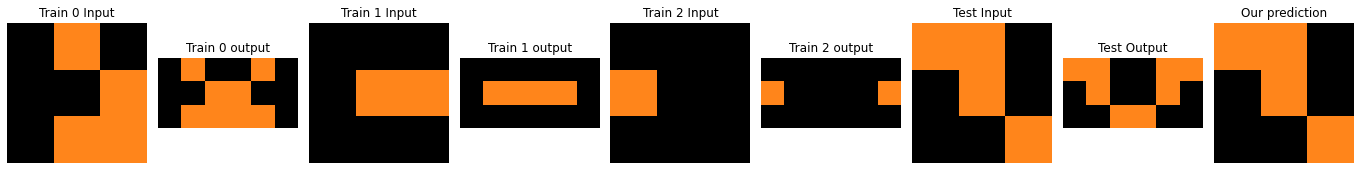

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
318
contraction:
[[0], [0], [0], [0]] [[(3, 3)], [(8, 11)], [(2, 4)], [(9, 8)]]


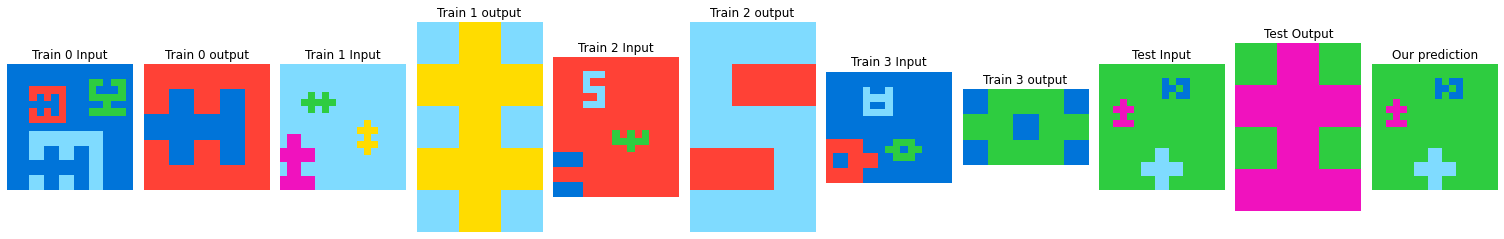

is_out_obj_in_in_objs: [(True, 2), (False, -1)]
overall_movement: [(True, (3, 3)), (False, ())]
325
contraction:
[[0, 5, 4, 5, 0, 3, 4, 3, 0], [0, 5, 4, 3, 3, 4, 5, 0, 0, 5, 4, 3, 3, 4, 5, 0], [0, 5, 4, 5, 0, 3, 4, 3, 0, 3, 4, 5, 0, 5, 4, 5, 0, 3]] [[(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4)], [(0, 0), (0, 2), (0, 4), (0, 6), (2, 0), (2, 2), (2, 4), (2, 6), (4, 0), (4, 2), (4, 4), (4, 6), (6, 0), (6, 2), (6, 4), (6, 6)], [(0, 0), (0, 2), (0, 4), (2, 0), (2, 2), (2, 4), (4, 0), (4, 2), (4, 4), (6, 0), (6, 2), (6, 4), (8, 0), (8, 2), (8, 4), (10, 0), (10, 2), (10, 4)]]


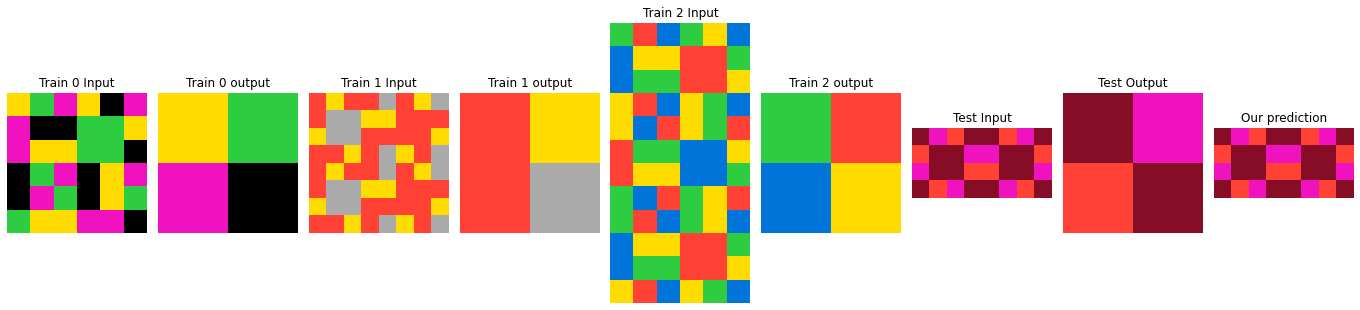

is_out_obj_in_in_objs: []
overall_movement: []
350
contraction:
[[7, 4], [7, 5, 3, 2, 6, 4], [3, 1, 5, 4, 6]] [[(5, 2), (6, 2)], [(0, 8), (3, 11), (8, 0), (8, 11), (11, 3), (11, 8)], [(4, 0), (7, 0), (7, 11), (11, 4), (11, 7)]]


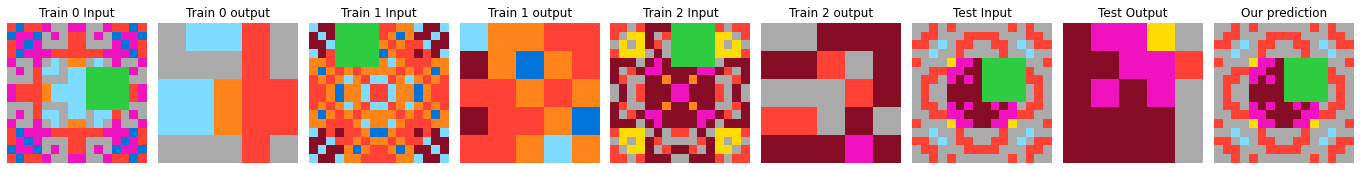

is_out_obj_in_in_objs: [(False, -1), (False, -1), (False, -1), (True, 12), (False, -1), (True, 17), (False, -1)]
overall_movement: [(False, ()), (False, ()), (False, ()), (True, (10, 5)), (False, ()), (True, (5, 2)), (False, ())]
364
contraction:
[[0], [0], [0]] [[(0, 6)], [(7, 1)], [(0, 0)]]


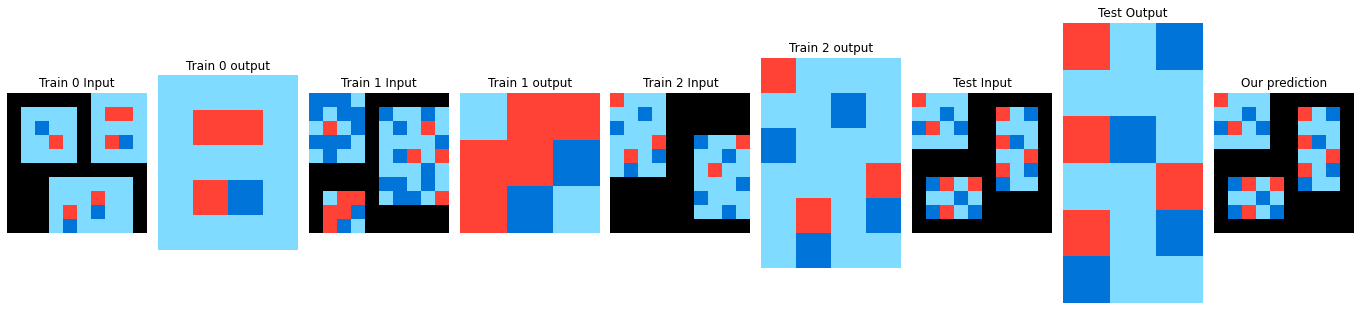

is_out_obj_in_in_objs: [(True, 1), (True, 4)]
overall_movement: [(True, (0, 6)), (True, (0, 6))]
375
expansion:
[[0, 4, 0, 4], [0, 4, 0, 4]] [[(0, 0), (2, 0), (4, 0), (6, 0)], [(0, 0), (3, 0), (6, 0), (9, 0)]]


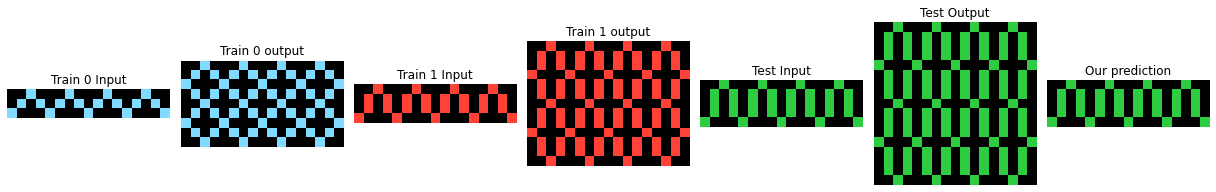

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]
399
contraction:
[[7, 3, 1, 5, 4, 6], [5, 1, 4, 7, 3], [4, 6, 2, 3, 5, 1]] [[(0, 1), (1, 0), (18, 0), (18, 19), (19, 1), (19, 18)], [(6, 8), (6, 11), (8, 13), (11, 13), (13, 11)], [(4, 9), (4, 10), (9, 4), (9, 15), (10, 4), (10, 15)]]


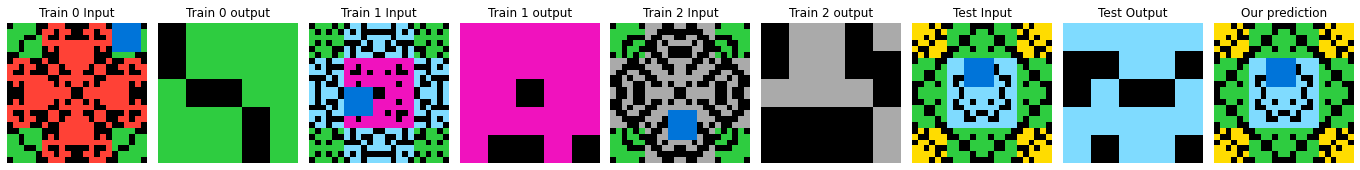

is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


In [33]:
tests = 0
for n in range(400):
    this_task = this_analysis[n]
    
    if this_task.is_out_in_rel and all([x[2] == this_task.out_in_rel[0][2] for x in this_task.out_in_rel]):
        scenario = this_task.out_in_rel[0][2]
        arrangements = [[j[0] for j in i[1]] for i in this_task.out_in_rel]
        steps = [[j[1] for j in i[1]] for i in this_task.out_in_rel]
        if scenario == 'contraction':
            print(n)
            print('contraction:')
            print(arrangements, steps)
            tests += 1
            plot_task_eval(tt[n], this_task.testinputs)
            print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
            print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))
        elif scenario == 'expansion' and all([len(x[1]) >= 2 for x in this_task.out_in_rel]):
            print(n)
            print('expansion:')
            print(arrangements, steps)
            tests += 1
            plot_task_eval(tt[n], this_task.testinputs)
            print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
            print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))

        

173
is_out_in_rel: True
(True, [(0, (6, 3))], 'contraction')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[6, 8, 3, 7, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6], [1, 3, 1, 5, 2, 4, 2, 5, 2, 5, 2, 5, 1, 5], [2, 4, 6, 9, 2, 3, 7, 4, 7, 4, 7, 4, 1, 4]]
this_task.trainoutput_objects: [[0, 2, 0, 4, 2, 4, 6, 6, 6, 6, 6, 6, 1, 6]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (6, 3))]


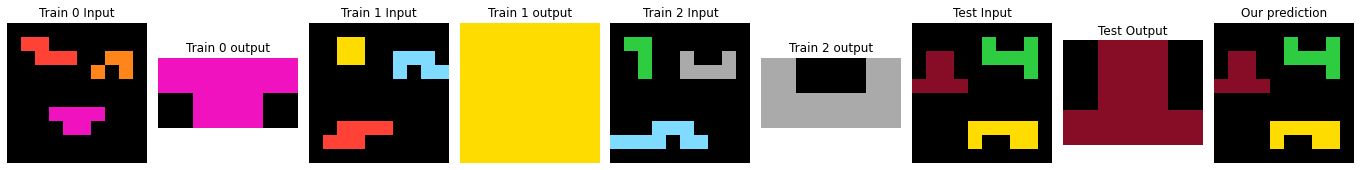

====
299
is_out_in_rel: True
(True, [(0, (1, 1))], 'contraction')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[1, 5, 1, 4, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8], [2, 5, 8, 11, 3, 3, 1, 6, 1, 6, 1, 6, 1, 6], [1, 3, 5, 7, 2, 2, 3, 3, 3, 3, 3, 3, 1, 3]]
this_task.trainoutput_objects: [[0, 4, 0, 3, 4, 3, 2, 8, 2, 8, 2, 8, 1, 8]]
is_out_obj_in_in_objs: [(True, 0)]
overall_movement: [(True, (1, 1))]


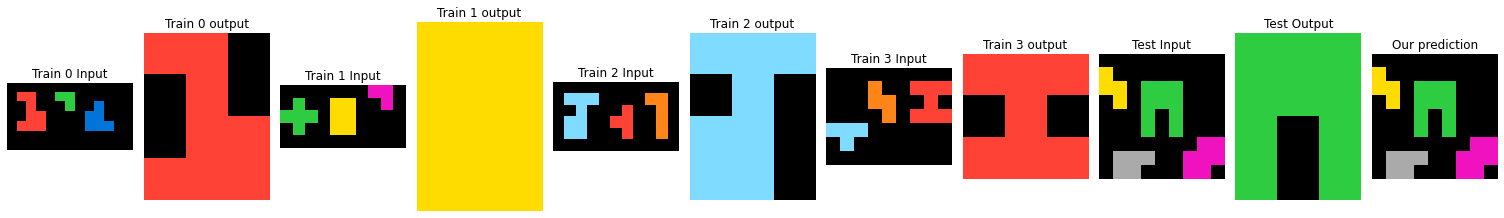

====
324
is_out_in_rel: False
(False, [], 'non_dimension_related')
trainoutput_dims_in_traininputs_objects: False
this_task.traininput_objects: [[1, 5, 1, 4, 4, 3, 8, 8, 8, 8, 8, 8, 1, 8], [6, 9, 4, 7, 3, 3, 8, 6, 8, 6, 8, 6, 1, 6], [10, 13, 1, 5, 3, 4, 8, 6, 8, 6, 8, 6, 1, 6], [12, 14, 7, 9, 2, 2, 8, 4, 8, 4, 8, 4, 1, 4]]
this_task.trainoutput_objects: [[0, 4, 0, 4, 4, 4, 8, 4, 8, 4, 8, 4, 1, 4]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


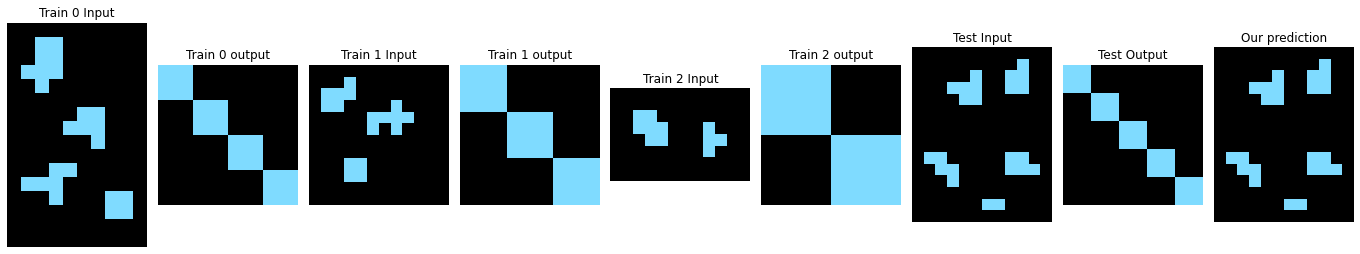

====
395
is_out_in_rel: False
(False, [], 'non_dimension_related')
trainoutput_dims_in_traininputs_objects: True
this_task.traininput_objects: [[3, 7, 10, 13, 4, 3, 2, 10, 2, 10, 2, 10, 1, 10], [9, 11, 9, 11, 2, 2, 4, 2, 4, 2, 4, 2, 1, 2], [2, 9, 0, 7, 7, 7, 2, 24, 2, 24, 4, 2, 2, 26]]
this_task.trainoutput_objects: [[0, 7, 0, 7, 7, 7, 4, 26, 4, 26, 4, 26, 1, 26]]
is_out_obj_in_in_objs: [(False, -1)]
overall_movement: [(False, ())]


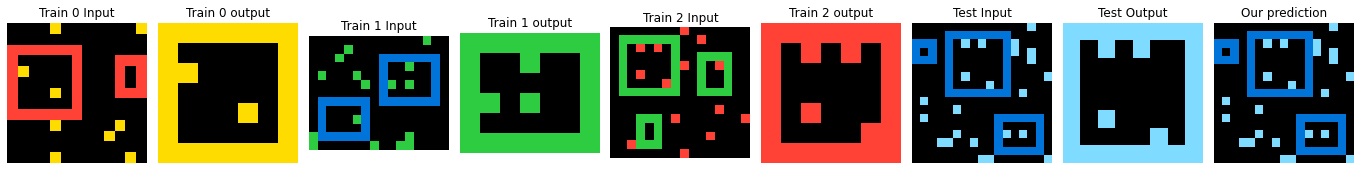

====


In [8]:
expansion_contractiosn = 0
for n in range(400):
    this_task = this_analysis[n]
    if (this_task.is_out_in_rel and this_task.dimension_status == 'deduced' and not this_task.is_same_dim_couple and (this_task.is_sim_int_div or this_task.is_sim_internal_int_div)) or this_task.is_one_object_in_output:
        print(n)
        print('is_out_in_rel:', this_task.is_out_in_rel)
        print(this_task.out_in_rel[0])    
        print('trainoutput_dims_in_traininputs_objects:', this_task.trainoutput_dims_in_traininputs_objects)
        print('this_task.traininput_objects:', this_task.traininput_objects[0])
        print('this_task.trainoutput_objects:', this_task.trainoutput_objects[0])
        print('is_out_obj_in_in_objs:', [is_out_obj_in_in_objs(x, this_task.traininput_objects[0]) for x in this_task.trainoutput_objects[0]])
        print('overall_movement:', overall_movement(this_task.trainoutput_objects[0], this_task.traininput_objects[0]))
        plot_task_eval(tt[n], this_task.testinputs)
        expansion_contractiosn += 1
        print('====')

In [23]:
expansion_contractiosn

83

In [ ]:
opportunities = 0
for n in range(len(this_analysis)) :
    this_task = this_analysis[n]
    if this_task.dimension_status == 'undeduced':
        plot_task_eval(tt[n], this_task.testinputs)
        print(n)
        print('is_out_in_rel:', this_task.is_out_in_rel)
        print(this_task.row_dim_ouputs, this_task.col_dim_ouputs, this_task.is_one_row, this_task.is_one_col, this_task.is_one_row_or_column, this_task.is_unique_train_outputs, this_task.bg_in_unique_train_outputs)
        print('Input dimensions: ', this_task.traininputs_shapes[0])
        print('Output dimensions: ', this_task.trainoutputs_shapes[0])
        num_cells_traininputs = [x[0] * x[1] for x in this_task.traininputs_shapes]
        num_cells_trainoutputs = [x[0] * x[1] for x in this_task.trainoutputs_shapes]
        print('num_calls:', num_cells_traininputs[0], num_cells_trainoutputs[0])
        freqs_traininputs = [np.unique(x, return_counts = True) for x in this_task.traininputs]
        freqs_trainoutputs = [np.unique(x, return_counts = True) for x in this_task.trainoutputs]
        freqs_traininputs = [sort_two_lists_based_on_second(x[0].tolist(), x[1].tolist()) for x in freqs_traininputs]
        freqs_trainoutputs = [sort_two_lists_based_on_second(x[0].tolist(), x[1].tolist()) for x in freqs_trainoutputs]
        print('freqs:', freqs_traininputs,freqs_trainoutputs[0])
        print('bg: ', this_task.bg)
        print('Traininput_objects:', this_task.traininput_objects[0])
        print('traininput_ex:')
        assess_connected_components_from_coordinates(this_task.traininputs[0], this_task.global_bg, this_task.bg)
        print('Trainotput_objects:', this_task.trainoutput_objects[0])
        print('trainoutput_ex:')
        assess_connected_components_from_coordinates(this_task.trainoutputs[0], this_task.global_bg, this_task.bg)
        print('====')


In [ ]:
# Action:
# single solutions
# this_task.out_in_rel, this_task.is_out_in_rel, 
# this_task.traininput_objects_dims, this_task.traininput_objects

# 106: dim is input dim * number of nonbg: dimensions determined by len of freq_nonbg (2, 3, 4)
# 299 (dim and soln): output the object with the most frequent nonbg: use freqs of traininputs and traininput_objects to find that
# the most frequent value of the output object is the most frequent value in the freqs_nonbg. We thought 173
# could be solved this way but it turns that the next level is to spit multiple objects in the scenario the system 
# can't find a rule (so, 299 wull be solved logically, 173 will be solved stochatically/heuristically) until
# the system evolves enough
# 212 (dim, needs sense of orientation for soln): the only square
# 220 true convolve, expansion: (dim, is_sim_internal_int_div) multiply the current dimension with the 
# number of bg find out where this is

# 246: interesting, the dimension is the maximum frequenct
# multiplied by 1 if it is not repeated or it is multiplied by its repetiton notice it is not the value
# 268, 288 (output dim is the input dim * num_unique_nonbg): (dim) dim is multiplied with the number of unique nonbg
# 274: output dim is a square of a side = square root of row dim of the input
# 294(output_dim = [input_x*input_y/2, input_y], 397([input_y*num_unique_nobg, input_y*num_unique_nobg]): single row expands to half the columns, single row expoands to a square of largest dim multiplied with 
# the number of nonbg
# 338 (0utput_dim = [1, num_nonbg]): (dim and soln): dim is one row and num of columns == frequency of the only unqiue nonbg
#

# Multiple solutions: have to do this ya man
# 187: you have multiples from convolutions, it is just not clear whether why split
# horizontally or vertically (give two solutions in this case)
# 173 : thought we got it, it is more difficult thant this


# incomplete implementation:
# 215 shows that the find_objects of scipy can't solve these porblems, Our colvolution
# method is not applicable to unseen cases since it starts with the target. we need to
# implement the test compatiblel version of convolve that spits objects not identified
# by scipy and this starts with bridging the gap between scipy and the real world object 
# detection which we started with an easy search convolution.
# 173 : thought we got it, it is more difficult thant this
# 364 similar situation, better object detection is going to be needed
# 395 is the same


# Intractable at the moment.
# 114, 177: row_dim_ouputs, col_dim_ouputs, is_one_row
#      the non-1 dim is the len of freqs (3, 3, 4) which is determined
# based on whether colors are stacked vertically of horizontally
# we have a hige gab of prior knowledge on orientation
# in theory this should be easy to implement
# 20 (unique output, true contraction, other infor is irrelevant), 45: dimensions and solutions are determined by identifying horizontal
# and or vertical lines of nonbg or a bg respectively.

# 134: return rectangle with the largest number of red dots and extend
# these dots into lines
# 304 is similar but returns the rectangle (blue) with a few red dots and go ahead and extend them
# 

# 95, 169, 183, 217, 232, 238, 243,  is sort of higher rank
